In [ ]:
import os, shutil, json
from sklearn.model_selection import train_test_split

# 1. Rename and copy raw image to nnUNet_raw folder

Train: 53 patients, Test: 22 patients

In [ ]:
raw_dir = "/media/storage/luu/BrainMRIReview/raw/MSLesSeg/train"
nnUNet_raw = "/media/storage/luu/nnUNet_raw/Dataset333_MSLesSeg"
nnUNet_raw_imagesTr = os.path.join(nnUNet_raw, "imagesTr")
nnUNet_raw_labelsTr = os.path.join(nnUNet_raw, "labelsTr")
nnUNet_raw_imagesTs = os.path.join(nnUNet_raw, "imagesTs")
nnUNet_raw_labelsTs = os.path.join(nnUNet_raw, "labelsTs")

In [3]:
patients = os.listdir(raw_dir)
train_patients, test_patients = train_test_split(patients, test_size=0.1, random_state=42)
n_train = len(train_patients)
n_test = len(test_patients)

print(f"{n_train} training patients, {n_test} testing patients.")
print(f"Testing patients: {test_patients}")

47 training patients, 6 testing patients.
Testing patients: ['P26', 'P47', 'P52', 'P2', 'P49', 'P13']


In [ ]:
channel_name_to_modality = {
    "1": "T1",
    "2": "T2",
    "3": "FLAIR"
}
modality_to_channel_name = {
    "T1": "1",
    "T2": "2",
    "FLAIR": "3"
}

def get_path_dict(patients, patient_dir, output_images_dir, output_labels_dir=None):
    path_dict = {}

    for patient in patients:
        path_dict[patient] = []
        patient_path = os.path.join(patient_dir, patient)
        timepoints = os.listdir(patient_path)
        for timepoint in timepoints:
            tp_path = os.path.join(patient_path, timepoint)
            images = os.listdir(tp_path)
            for image in images:
                # Create nnUNet_raw path
                image_id = image.replace(".nii.gz", "") # P26_T1_T1
                modality = image_id.split("_")[-1] # T1
                session_id = "_".join(image_id.split("_")[:-1]) # P26_T1

                if modality == "MASK":
                    new_image_id = session_id
                    if output_labels_dir is None:
                        raise ValueError("Missing dir for saving labels.")
                    new_image_path = os.path.join(output_labels_dir, f"{new_image_id}.nii.gz")
                else:
                    channel = modality_to_channel_name[modality]
                    new_image_id = f"{session_id}_000{channel}"
                    new_image_path = os.path.join(output_images_dir, f"{new_image_id}.nii.gz")
                
                # Original path
                original_image_path = os.path.join(tp_path, image)
                
                # Save a pair of original image path and nnUNet_raw image path
                path_dict[patient].append((original_image_path, new_image_path))
    
    return path_dict

# Copy training data
def save_path_dict_for_train():
    path_dict = get_path_dict(
        patients=train_patients,
        patient_dir=raw_dir,
        output_images_dir=nnUNet_raw_imagesTr,
        output_labels_dir=nnUNet_raw_labelsTr
    )

    output_path = os.path.join(nnUNet_raw, "path_dict_train.json")
    with open(output_path, "w") as f:
        json.dump(path_dict, f, indent=4)

    return path_dict

def save_path_dict_for_test():
    path_dict = get_path_dict(
        patients=test_patients,
        patient_dir=raw_dir,
        output_images_dir=nnUNet_raw_imagesTs,
        output_labels_dir=nnUNet_raw_labelsTs
    )

    output_path = os.path.join(nnUNet_raw, "path_dict_test.json")
    with open(output_path, "w") as f:
        json.dump(path_dict, f, indent=4)
        
    return path_dict

# Copy from original path to nnUNet_path
def copy_files(path_dict):
    
    current_patient = 0
    total_patient = len(path_dict)

    for patient, paths in path_dict.items():
        current_patient += 1
        print(f"[{current_patient}/{total_patient}] Copying patient {patient}...")
        
        for src, dst in paths:
            #print(src, dst)
            shutil.copyfile(src=src, dst=dst)


In [ ]:
# train_path_dict = save_path_dict_for_train()
# test_path_dict = save_path_dict_for_test()

# copy_files(train_path_dict)
# copy_files(test_path_dict)

# 2. Visualize prediction

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

In [14]:
model_name = "nnUNet"
prediction_dir = f"/media/storage/luu/SmallLesionMRI/MSLesSeg/{model_name}"
gt_images_dir = "/media/storage/luu/nnUNet_raw/Dataset333_MSLesSeg/imagesTs"
gt_labels_dir = "/media/storage/luu/nnUNet_raw/Dataset333_MSLesSeg/labelsTs"
metrics_csv = f"metrics/metrics_MSLesSeg_{model_name}.csv"

In [15]:
df = pd.read_csv(metrics_csv)
df

,sample,DICE,Hausdorff,Sensitivity,Specificity,True_volume,Predicted_volume
0,P13_T1.nii.gz,0.754983,7.810250,0.663429,0.999874,9.677,7.330
1,P13_T2.nii.gz,0.823734,2.000000,0.855181,0.999685,10.268,11.052
2,P26_T1.nii.gz,0.813862,8.185353,0.776472,0.999879,6.639,6.029
3,P2_T1.nii.gz,0.865361,1.414214,0.791685,0.999988,2.261,1.876
4,P2_T2.nii.gz,0.775844,26.153394,0.692027,0.999958,3.286,2.576
5,P2_T3.nii.gz,0.816097,1.414214,0.773161,0.999956,2.623,2.347
6,P2_T4.nii.gz,0.802373,12.884099,0.874150,0.999876,2.940,3.466
7,P47_T1.nii.gz,0.836228,1.000000,0.903288,0.999331,18.736,21.741
8,P49_T1.nii.gz,0.854193,6.708204,0.774813,0.999810,34.709,28.258
9,P49_T2.nii.gz,0.621702,5.830952,0.550947,0.999762,7.763,5.996


In [16]:
mean_dice = df["DICE"].mean()
mean_hd   = df["Hausdorff"].mean()
mean_sen  = df["Sensitivity"].mean()
mean_spe  = df["Specificity"].mean()

print(f"Mean Dice={mean_dice:.4f}\nMean HD={mean_hd:.4f}\nMean Sensitivity={mean_sen:.4f}\nMean Specificity={mean_spe:.4f}")

Mean Dice=0.7896
Mean HD=9.5907
Mean Sensitivity=0.7716
Mean Specificity=0.9998


In [17]:
sorted_df = df.sort_values(by="DICE", ascending=False)
sorted_df

,sample,DICE,Hausdorff,Sensitivity,Specificity,True_volume,Predicted_volume
3,P2_T1.nii.gz,0.865361,1.414214,0.791685,0.999988,2.261,1.876
8,P49_T1.nii.gz,0.854193,6.708204,0.774813,0.999810,34.709,28.258
7,P47_T1.nii.gz,0.836228,1.000000,0.903288,0.999331,18.736,21.741
1,P13_T2.nii.gz,0.823734,2.000000,0.855181,0.999685,10.268,11.052
10,P52_T1.nii.gz,0.818398,1.414214,0.831518,0.999908,3.306,3.412
5,P2_T3.nii.gz,0.816097,1.414214,0.773161,0.999956,2.623,2.347
2,P26_T1.nii.gz,0.813862,8.185353,0.776472,0.999879,6.639,6.029
6,P2_T4.nii.gz,0.802373,12.884099,0.874150,0.999876,2.940,3.466
4,P2_T2.nii.gz,0.775844,26.153394,0.692027,0.999958,3.286,2.576
0,P13_T1.nii.gz,0.754983,7.810250,0.663429,0.999874,9.677,7.330


Text(0.5, 0, 'Worst Case - P49_T2')

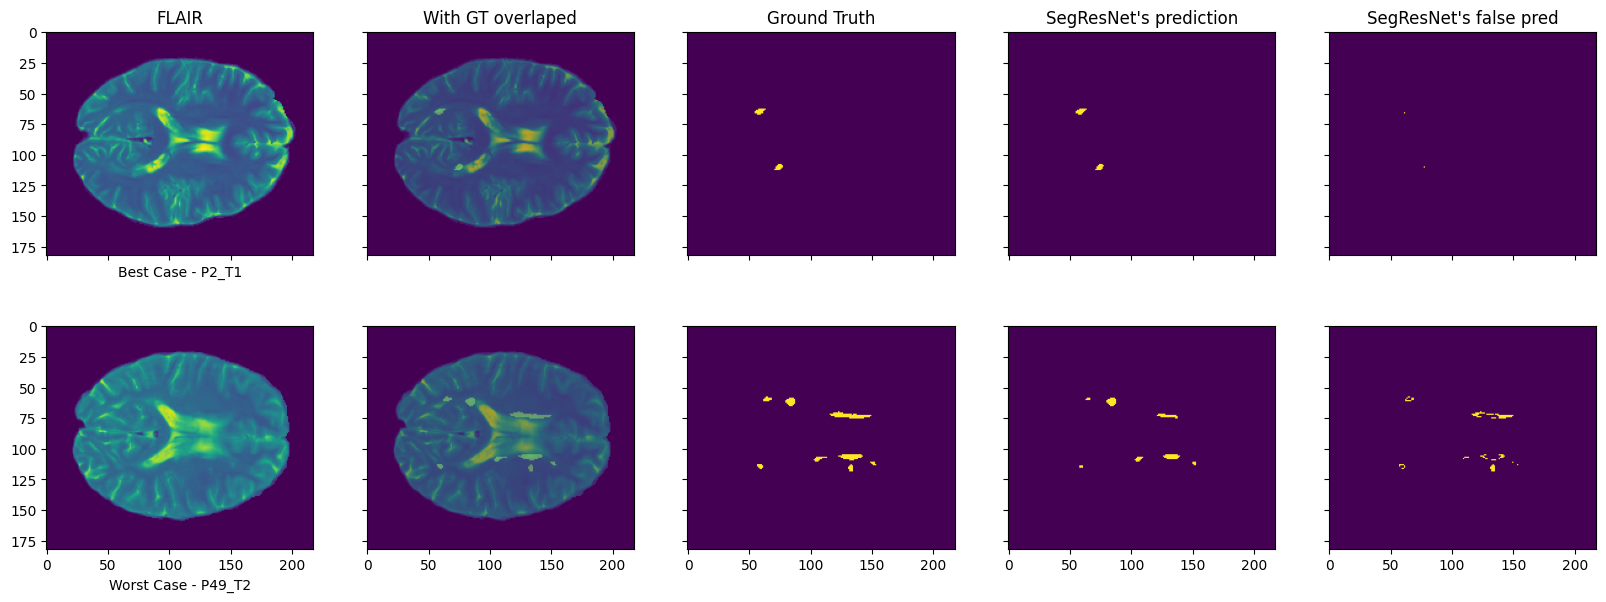

In [18]:
# Visualize best and worst case
slice_idx = 90
fig, axs = plt.subplots(2, 5, figsize=(20, 7), sharex=True, sharey=True)

# Set titles
axs[0,0].set_title("FLAIR")
axs[0,1].set_title("With GT overlaped")
axs[0,2].set_title("Ground Truth")
axs[0,3].set_title("SegResNet's prediction")
axs[0,4].set_title("SegResNet's false pred")


# Show best case
best_fn = sorted_df.iloc[0,0]
best_id = best_fn.replace(".nii.gz", "")
best_img = nib.load(os.path.join(gt_images_dir, f"{best_id}_0002.nii.gz")).get_fdata()
best_gt = nib.load(os.path.join(gt_labels_dir, best_fn)).get_fdata()
best_pred = nib.load(os.path.join(prediction_dir, best_fn)).get_fdata()
best_missed = np.abs(best_gt - best_pred)

axs[0,0].imshow(best_img[...,slice_idx])
axs[0,1].imshow(best_img[...,slice_idx])
axs[0,1].imshow(best_gt[...,slice_idx], alpha=0.3)
axs[0,2].imshow(best_gt[...,slice_idx])
axs[0,3].imshow(best_pred[..., slice_idx])
axs[0,4].imshow(best_missed[..., slice_idx])


# Show worst case
worst_fn = sorted_df.iloc[-1,0]
worst_id = worst_fn.replace(".nii.gz", "")
worst_img = nib.load(os.path.join(gt_images_dir, f"{worst_id}_0002.nii.gz")).get_fdata()
worst_gt = nib.load(os.path.join(gt_labels_dir, worst_fn)).get_fdata()
worst_pred = nib.load(os.path.join(prediction_dir, worst_fn)).get_fdata()
worst_missed = np.abs(worst_gt - worst_pred)

axs[1,0].imshow(worst_img[...,slice_idx])
axs[1,1].imshow(worst_img[...,slice_idx])
axs[1,1].imshow(worst_gt[...,slice_idx], alpha=0.3)
axs[1,2].imshow(worst_gt[...,slice_idx])
axs[1,3].imshow(worst_pred[..., slice_idx])
#axs[1,4].imshow(worst_pred[..., slice_idx])
axs[1,4].imshow(worst_missed[..., slice_idx])

# Show id of best and worst cases
axs[0,0].set_xlabel(f"Best Case - {best_id}")
axs[1,0].set_xlabel(f"Worst Case - {worst_id}")


<!-- # Notes:
1. What is the small lesions? (how much cm?) (*)
2. Compare predictions over timepoints of the same patient
3. Task: Identiy small lesions, classify small tumors, evaluate the size/volumne of the lesion
4. Dataset: MS, metastasis, maybe stroke. -->

In [7]:
# Visualize predictions of a patient with multiple timepoints
def plot_prediction_timepoints(patient_id, n_timepoints):
    slice_idx = 90
    fig, axs = plt.subplots(n_timepoints, 5, figsize=(20, n_timepoints*3), sharex=True, sharey=True)

    # Set titles
    axs[0,0].set_title("FLAIR")
    axs[0,1].set_title("With GT overlaped")
    axs[0,2].set_title("Ground Truth")
    axs[0,3].set_title("SegResNet's prediction")
    axs[0,4].set_title("SegResNet's false pred")

    # Set xlabels
    for j in range(n_timepoints):
        axs[j,0].set_xlabel(f"Timepoint {j+1}")


    for i in range(n_timepoints):
        sample_id = f"{patient_id}_T{i+1}"
        sample_fn = f"{sample_id}_0002.nii.gz"
        sample_img = nib.load(os.path.join(gt_images_dir, sample_fn)).get_fdata()
        sample_gt = nib.load(os.path.join(gt_labels_dir, f"{sample_id}.nii.gz")).get_fdata()
        sample_pred = nib.load(os.path.join(prediction_dir, f"{sample_id}.nii.gz")).get_fdata()
        sample_missed = np.abs(sample_gt - sample_pred)


        axs[i,0].imshow(best_img[...,slice_idx])
        axs[i,1].imshow(best_img[...,slice_idx])
        axs[i,1].imshow(best_gt[...,slice_idx], alpha=0.3)
        axs[i,2].imshow(best_gt[...,slice_idx])
        axs[i,3].imshow(best_pred[..., slice_idx])
        axs[i,4].imshow(best_missed[..., slice_idx])


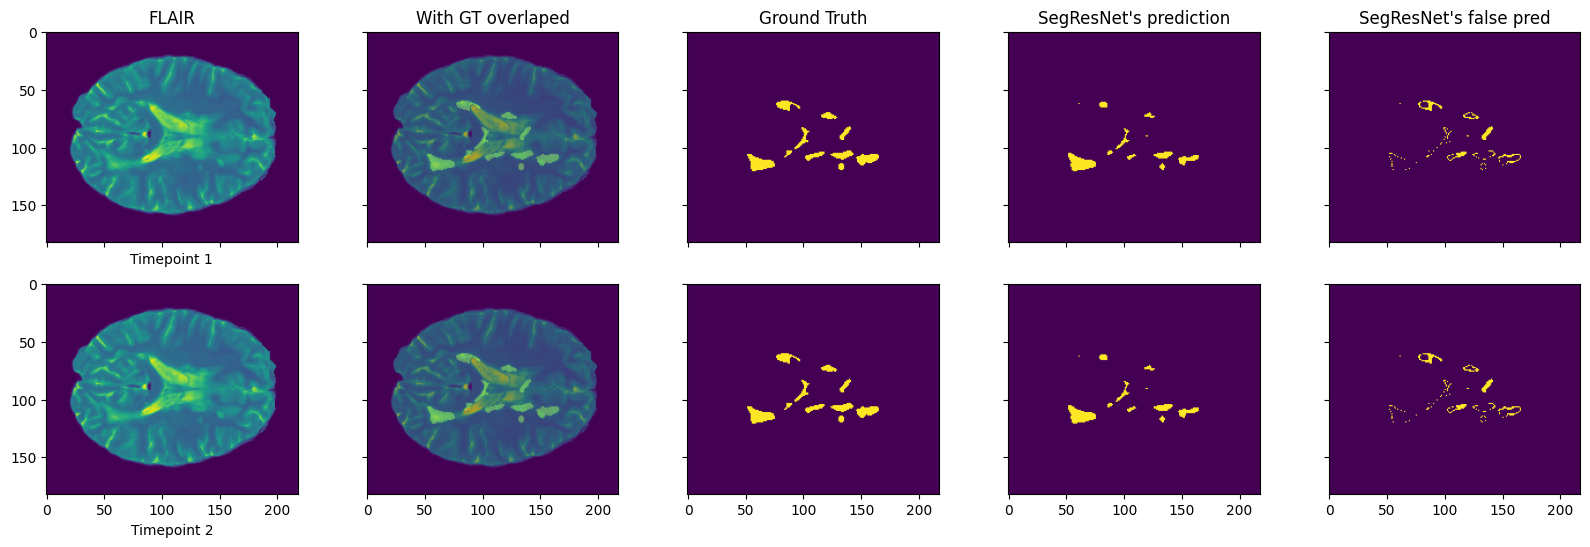

In [13]:
plot_prediction_timepoints(patient_id="P52", n_timepoints=2)

# 3. Compare metrics across models

In [3]:
import pandas as pd

In [4]:
nnUNet_csv = "metrics/metrics_MSLesSeg_nnUNet.csv"
unetr_csv = "metrics/metrics_MSLesSeg_UNETR.csv"
swin_csv = "metrics/metrics_MSLesSeg_SwinUNETR.csv"
segresnet_csv = "metrics/metrics_MSLesSeg_SegResNet.csv"
umbot_csv = "metrics/metrics_MSLesSeg_UMambaBot.csv"
umenc_csv = "metrics/metrics_MSLesSeg_UMambaEnc.csv"

nnUNet_df = pd.read_csv(nnUNet_csv)
unetr_df = pd.read_csv(unetr_csv)
swin_df = pd.read_csv(swin_csv)
segresnet_df = pd.read_csv(segresnet_csv)
umbot_df = pd.read_csv(umbot_csv)
umenc_df = pd.read_csv(umenc_csv)


In [5]:
def print_mean_metrics(csvs):
    for csv in csvs:
        ds_name = csv.split("_")[-1].replace(".csv", "")
        df = pd.read_csv(csv)
        mean_dice = df["DICE"].mean()
        mean_HD = df["Hausdorff"].mean()
        print(f"{ds_name}: Mean Dice={mean_dice:.4f}, Mean HD={mean_HD:.4f}")

print_mean_metrics([
    nnUNet_csv, segresnet_csv, unetr_csv, swin_csv, umbot_csv, umenc_csv
])

nnUNet: Mean Dice=0.7896, Mean HD=9.5907
SegResNet: Mean Dice=0.7697, Mean HD=14.1651
UNETR: Mean Dice=0.7474, Mean HD=23.2578
SwinUNETR: Mean Dice=0.7777, Mean HD=13.9264
UMambaBot: Mean Dice=0.7851, Mean HD=10.4546
UMambaEnc: Mean Dice=0.7828, Mean HD=12.9222


/tmp/ipykernel_2532643/818479221.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dice_data, labels=labels, showfliers=True)


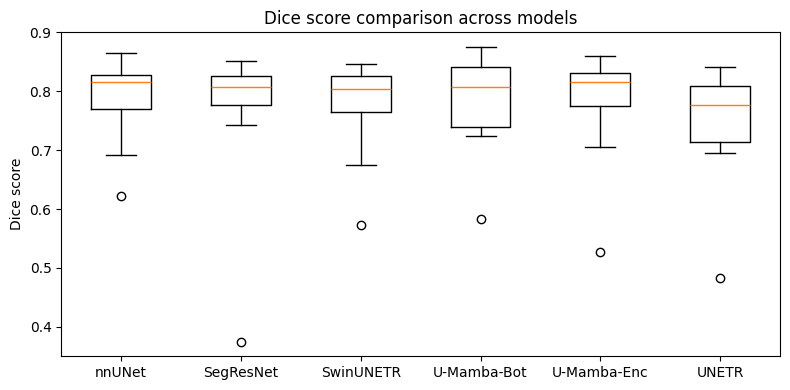

In [ ]:
# Compare models by Dice Score
files = {
    "nnUNet": "metrics/metrics_MSLesSeg_nnUNet.csv",
    "SegResNet": "metrics/metrics_MSLesSeg_SegResNet.csv",
    "SwinUNETR": "metrics/metrics_MSLesSeg_SwinUNETR.csv",
    "U-Mamba-Bot": "metrics/metrics_MSLesSeg_UMambaBot.csv",
    "U-Mamba-Enc": "metrics/metrics_MSLesSeg_UMambaEnc.csv",
    "UNETR": "metrics/metrics_MSLesSeg_UNETR.csv",
}

dice_data = []
labels = []

for model, path in files.items():
    df = pd.read_csv(path)
    dice_data.append(df["DICE"].values)
    labels.append(model)

# ---------------- Box plot ----------------
plt.figure(figsize=(8, 4))
plt.boxplot(dice_data, labels=labels, showfliers=True)
plt.ylabel("Dice score")
plt.title("Dice score comparison across models")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2532643/4146372912.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(hd_data, labels=labels, showfliers=True)


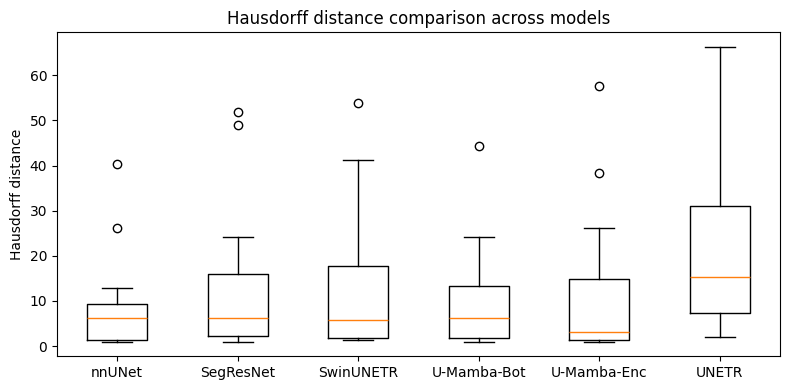

In [ ]:
# Compare HD distance (worst case mismatch)
hd_data = []
labels = []

for model, path in files.items():
    df = pd.read_csv(path)
    hd_data.append(df["Hausdorff"].values)
    labels.append(model)

# ---------------- Box plot ----------------
plt.figure(figsize=(8, 4))
plt.boxplot(hd_data, labels=labels, showfliers=True)
plt.ylabel("Hausdorff distance")
plt.title("Hausdorff distance comparison across models")
plt.tight_layout()
plt.show()

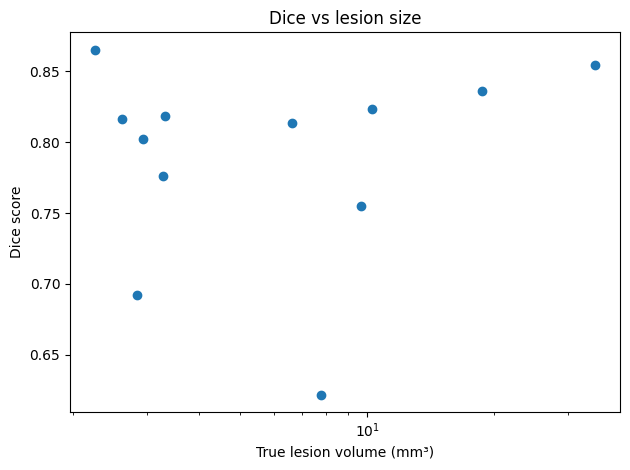

In [46]:
df = pd.read_csv("metrics/metrics_MSLesSeg_nnUNet.csv")

plt.figure()
plt.scatter(df["True_volume"], df["DICE"])
plt.xscale("log")
plt.xlabel("True lesion volume (mm³)")
plt.ylabel("Dice score")
plt.title("Dice vs lesion size")
plt.tight_layout()
plt.show()

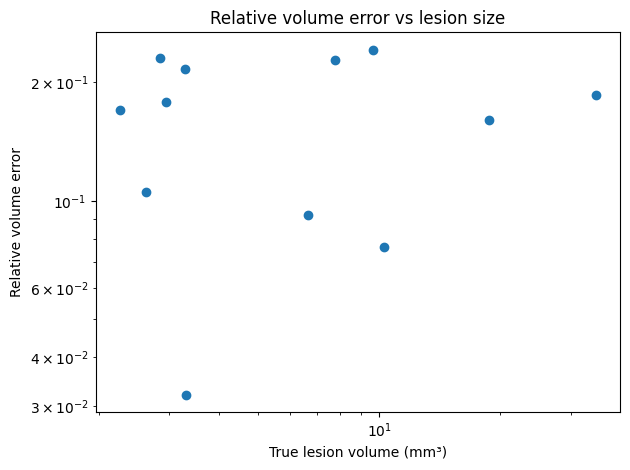

In [40]:
df["RVE"] = (
    (df["Predicted_volume"] - df["True_volume"]).abs()
    / df["True_volume"]
)

plt.figure()
plt.scatter(df["True_volume"], df["RVE"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("True lesion volume (mm³)")
plt.ylabel("Relative volume error")
plt.title("Relative volume error vs lesion size")
plt.tight_layout()
plt.show()

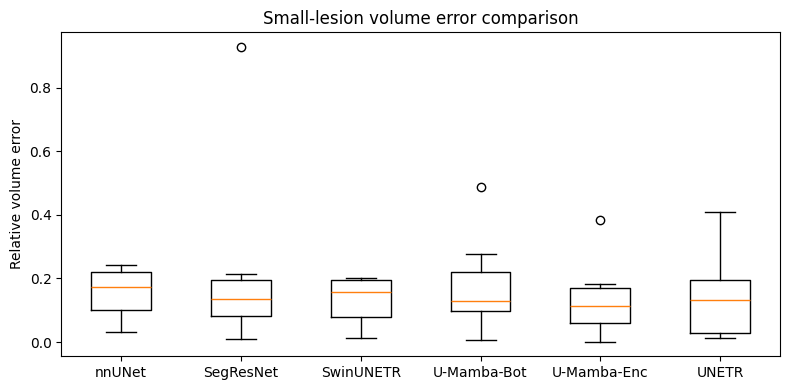

In [52]:
threshold = 3000  # mm³

rve_data = []
labels = []

for model, path in files.items():
    df = pd.read_csv(path)
    small = df[df["True_volume"] < threshold]
    rve = (
        (small["Predicted_volume"] - small["True_volume"]).abs()
        / small["True_volume"]
    )
    rve_data.append(rve.values)
    labels.append(model)

plt.figure(figsize=(8, 4))
plt.boxplot(rve_data, tick_labels=labels, showfliers=True)
plt.ylabel("Relative volume error")
plt.title("Small-lesion volume error comparison")
plt.tight_layout()
plt.show()

In [42]:
# Worst DICE cases of models
files = {
    "nnUNet": "metrics/metrics_MSLesSeg_nnUNet.csv",
    "SegResNet": "metrics/metrics_MSLesSeg_SegResNet.csv",
    "SwinUNETR": "metrics/metrics_MSLesSeg_SwinUNETR.csv",
    "UMambaBot": "metrics/metrics_MSLesSeg_UMambaBot.csv",
    "UMambaEnc": "metrics/metrics_MSLesSeg_UMambaEnc.csv",
    "UNETR": "metrics/metrics_MSLesSeg_UNETR.csv",
}

worst = {}

for model_name, csv_path in files.items():
    df = pd.read_csv(csv_path)
    sorted_df = df.sort_values(by="DICE").reset_index() 
    worst_case = sorted_df.loc[0, "sample"]
    worst_dice = sorted_df.loc[0, "DICE"]
    worst[model_name] = {
        "sample": worst_case,
        "worst_dice": worst_dice,
        "path": f"/media/storage/luu/SmallLesionMRI/MSLesSeg/{model_name}/{worst_case}"
    }

worst
    

{'nnUNet': {'sample': 'P49_T2.nii.gz',
  'worst_dice': np.float64(0.6217021585871066),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/nnUNet/P49_T2.nii.gz'},
 'SegResNet': {'sample': 'P49_T2.nii.gz',
  'worst_dice': np.float64(0.3749889993839655),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/SegResNet/P49_T2.nii.gz'},
 'SwinUNETR': {'sample': 'P49_T2.nii.gz',
  'worst_dice': np.float64(0.5722663233926911),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/SwinUNETR/P49_T2.nii.gz'},
 'UMambaBot': {'sample': 'P49_T2.nii.gz',
  'worst_dice': np.float64(0.5824316264803613),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/UMambaBot/P49_T2.nii.gz'},
 'UMambaEnc': {'sample': 'P49_T2.nii.gz',
  'worst_dice': np.float64(0.5278671643712189),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/UMambaEnc/P49_T2.nii.gz'},
 'UNETR': {'sample': 'P49_T2.nii.gz',
  'worst_dice': np.float64(0.4820929641859284),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/UNETR/P49_T

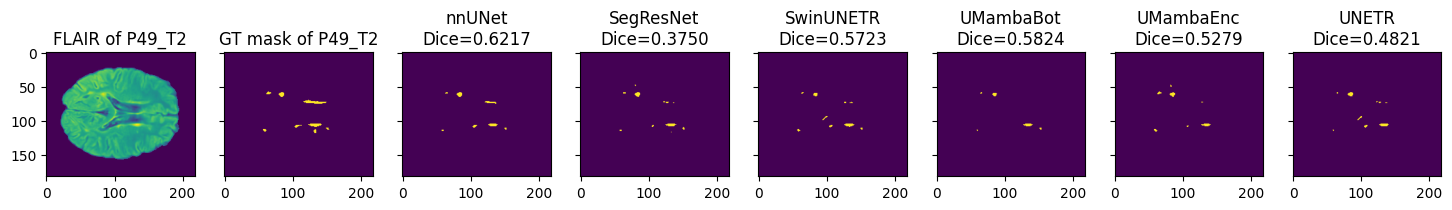

In [34]:
fig, axs = plt.subplots(1, 8, figsize=(18,5), sharex=True, sharey=True)

img_path = "/media/storage/luu/nnUNet_raw/Dataset333_MSLesSeg/imagesTs/P49_T2_0003.nii.gz"
img = nib.load(img_path).get_fdata()
axs[0].imshow(img[...,90])
axs[0].set_title(f"FLAIR of P49_T2")

img_path = "/media/storage/luu/nnUNet_raw/Dataset333_MSLesSeg/labelsTs/P49_T2.nii.gz"
img = nib.load(img_path).get_fdata()
axs[1].imshow(img[...,90])
axs[1].set_title(f"GT mask of P49_T2")

for i, (model_name, dict_) in enumerate(worst.items()):
    i += 2
    img_path = dict_["path"]
    img = nib.load(img_path).get_fdata()
    dice = dict_["worst_dice"]
    axs[i].imshow(img[...,90])
    axs[i].set_title(f"{model_name}\nDice={dice:.4f}")

In [43]:
best = {}

for model_name, csv_path in files.items():
    df = pd.read_csv(csv_path)
    sorted_df = df.sort_values(by="DICE", ascending=False).reset_index() 
    best_case = sorted_df.loc[0, "sample"]
    best_dice = sorted_df.loc[0, "DICE"]
    best[model_name] = {
        "sample": best_case,
        "worst_dice": best_dice,
        "path": f"/media/storage/luu/SmallLesionMRI/MSLesSeg/{model_name}/{worst_case}"
    }

best

{'nnUNet': {'sample': 'P2_T1.nii.gz',
  'worst_dice': np.float64(0.8653613729755861),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/nnUNet/P49_T2.nii.gz'},
 'SegResNet': {'sample': 'P49_T1.nii.gz',
  'worst_dice': np.float64(0.8519622931896883),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/SegResNet/P49_T2.nii.gz'},
 'SwinUNETR': {'sample': 'P2_T1.nii.gz',
  'worst_dice': np.float64(0.8460072018640119),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/SwinUNETR/P49_T2.nii.gz'},
 'UMambaBot': {'sample': 'P2_T1.nii.gz',
  'worst_dice': np.float64(0.8750591575958353),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/UMambaBot/P49_T2.nii.gz'},
 'UMambaEnc': {'sample': 'P49_T1.nii.gz',
  'worst_dice': np.float64(0.8599248108473723),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/UMambaEnc/P49_T2.nii.gz'},
 'UNETR': {'sample': 'P47_T1.nii.gz',
  'worst_dice': np.float64(0.8420172750069658),
  'path': '/media/storage/luu/SmallLesionMRI/MSLesSeg/UNETR/P49_T2.n

## Next step:

For lesion-driven analysis:
- Relative volume Error = `abs(V_true - V_pred) / V_true` for all models
- FP (oversegment) and FN (missing lesions) for case-by-case
- Hard to detect lesions vs small lesions:

        - Small volume: < 3000 mm3
        - Lesion-to-background contrast (mean_lesion - mean_local_bg) / std_local_bg, low means low contrast
        - Boundary sharpness

- Compare metrics on groups of lesions (small-blurry, small-low sharpness boundary, etc.) -> which properties breaks which model
- Find ways to quantitatively separate lesions as differnt objects -> Lesion-wise recall vs size

Architecture-driven analysis:
- Get probabilities and compare -> max proba inside GT 
- Add blur and observe segmentation drop
- Feature extraction at a layer, then train a simple Logistic Regression -> classify bg and lesion

For new datasets: (lesions, tumors)
- Train on Everest for faster


## Issue:
- There is no `nvcc` in my container on Everest, but I cannot do `apt update` because I got blocked. Yakov is helping this.


# Notes:

1. Filter lesions < 1000 mm3 (=1cm diameter) (for one lesion)
2. How to measure shaprness of boundary? (1.5T -> 3T, quality of data are different) -> need to discuss with radiologists
3. Lesion contrast -> discuss with Margarita bc it's related to the radiomic features.

# 4. Label Analysis

### 3D connected components

Separate lesions and measure volume of each one, then filter ones that are < 1000 cm3

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mrilite import load_nifti
from utils import (
    connected_components,
    show_slice_with_mask,
    compute_lesion_volume,
    compute_lesion_volumes_for_components,
    boundary_band_gradient_sharpness
)

In [5]:
# On Tunka
# img_path =  "/media/storage/luu/nnUNet_raw/Dataset333_MSLesSeg/imagesTs/P49_T2_0003.nii.gz"

# Local
img_path = "/Volumes/BACH2TB/Datasets/MSLesSeg/27919209/MSLesSeg Dataset/train/P49/T2/P49_T2_FLAIR.nii.gz"
mask_path = "/Volumes/BACH2TB/Datasets/MSLesSeg/27919209/MSLesSeg Dataset/train/P49/T2/P49_T2_MASK.nii.gz"

img_vol = load_nifti(img_path)
mask_vol = load_nifti(mask_path)

zoom = mask_vol.header.get_zooms()

img = img_vol.data
mask = mask_vol.data

img.shape, mask.shape

((182, 218, 182), (182, 218, 182))

In [11]:
lesion_cc, n_lesions = connected_components(mask, rank=3, connectivity=3)
lesion_cc.shape, n_lesions

((182, 218, 182), 19)

Text(0.5, 1.0, 'Lesion-wise connected components')

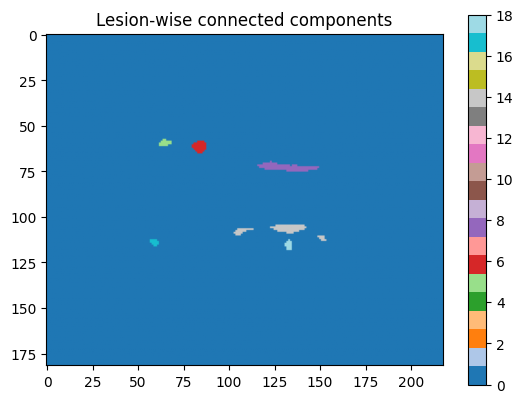

In [12]:
plt.imshow(lesion_cc[:, :, 90], cmap="tab20")
plt.colorbar()
plt.title("Lesion-wise connected components")

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: title={'center': 'MRI Slice 90 (axis=2)'}>,
        <Axes: title={'center': 'Segmentation Mask 90 (axis=2)'}>],
       dtype=object))

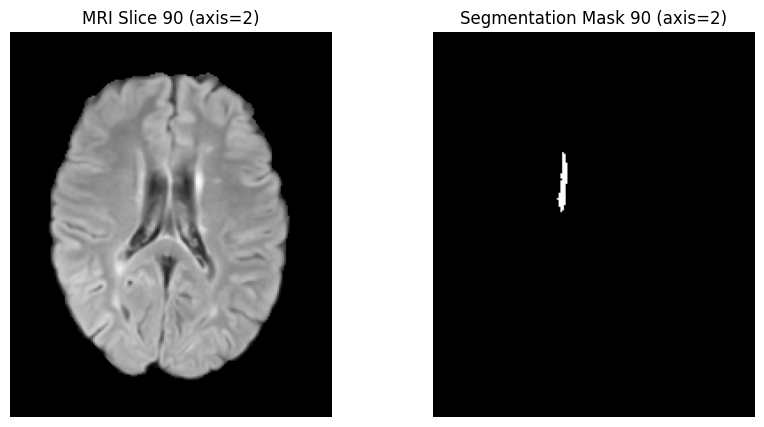

In [13]:
# Plot the lesion 8
lesion_id = 8
show_slice_with_mask(
    image=img,
    mask=(lesion_cc == lesion_id).astype(np.float32),
    slice_index=90,
    axis=2
)

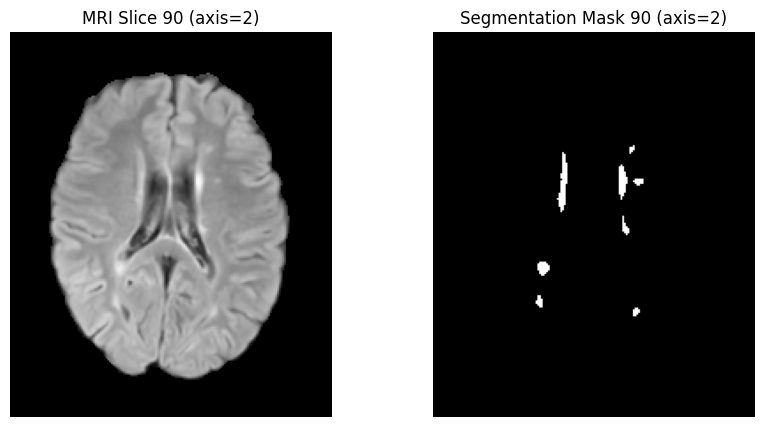

In [14]:
fig, axes = show_slice_with_mask(img, mask, slice_index=90, axis=2)

### Compute lesion volume

In [15]:
np.unique(mask), np.unique(lesion_cc)

(array([0., 1.], dtype=float32),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19], dtype=int32))

In [16]:
volume = compute_lesion_volume(mask, zoom, unit="mm3")
print(f"Lesion volume: {volume:.2f} mm³")

Lesion volume: 7763.00 mm³


In [17]:
volumes = compute_lesion_volumes_for_components(mask, zoom, unit="mm3")
for comp_id, vol in volumes.items():
    print(f"Lesion {comp_id}: {vol} mm³")

Lesion 1: 524.0 mm³
Lesion 2: 98.0 mm³
Lesion 3: 137.0 mm³
Lesion 4: 63.0 mm³
Lesion 5: 291.0 mm³
Lesion 6: 367.0 mm³
Lesion 7: 63.0 mm³
Lesion 8: 950.0 mm³
Lesion 9: 167.0 mm³
Lesion 10: 173.0 mm³
Lesion 11: 133.0 mm³
Lesion 12: 57.0 mm³
Lesion 13: 461.0 mm³
Lesion 14: 3256.0 mm³
Lesion 15: 294.0 mm³
Lesion 16: 150.0 mm³
Lesion 17: 334.0 mm³
Lesion 18: 57.0 mm³
Lesion 19: 188.0 mm³


### Lesion-to-background contrast

Measure how much the lesion stand out from the surrounding tissues.

In [6]:
from utils import (
    local_robust_cnr,
    zscore_normalize,
    lesion_background_ring,
    visualize_lesion_contrast,
    ContrastSelection
)

In [7]:
img.min(), img.max(), img.mean(), img.std()

(np.float32(0.0),
 np.float32(1471.0),
 np.float32(145.18512),
 np.float32(245.58936))

In [8]:
normalied_img = zscore_normalize(img, brain_mask=(img > 0))
print(normalied_img.min(), normalied_img.max(), normalied_img.mean(), normalied_img.std())

ring_mask = lesion_background_ring(
    lesion_mask=mask,
    ring_mm=3.0,
    spacing_mm=zoom,
    brain_mask=(img > 0)
)
cnr = local_robust_cnr(
    image_norm=normalied_img,
    lesion_mask=mask,
    ring_mask=ring_mask
)
cnr

-3.6692731 6.673701 -2.6484368 1.7267903


2.543478488922119

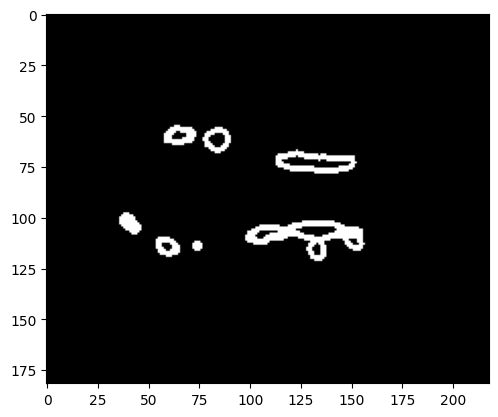

In [9]:
plt.imshow(ring_mask[:, :, 90], cmap="gray")

In [27]:
# Compute local CNR for each lesion
lesion_cnr = {}
for lesion_id in range(1, n_lesions + 1):
    lesion_mask = (lesion_cc == lesion_id).astype(np.uint8)

    ring_mask = lesion_background_ring(
        lesion_mask=lesion_mask,
        ring_mm=3.0,
        spacing_mm=zoom,
        brain_mask=(img > 0)
    )
    lesion_cnr[lesion_id] = local_robust_cnr(
        image_norm=normalied_img,
        lesion_mask=lesion_mask,
        ring_mask=ring_mask
    )

lesion_cnr

{1: 2.198275566101074,
 2: 2.8103444576263428,
 3: 3.84210467338562,
 4: 2.5517232418060303,
 5: 4.8125,
 6: 3.0833334922790527,
 7: 3.0,
 8: 3.0697672367095947,
 9: 3.2162160873413086,
 10: 3.6451609134674072,
 11: 2.5135138034820557,
 12: 2.999999523162842,
 13: 5.185185432434082,
 14: 3.0909087657928467,
 15: 2.471264362335205,
 16: 4.038461208343506,
 17: 4.716665744781494,
 18: 3.1666665077209473,
 19: 3.0833330154418945}

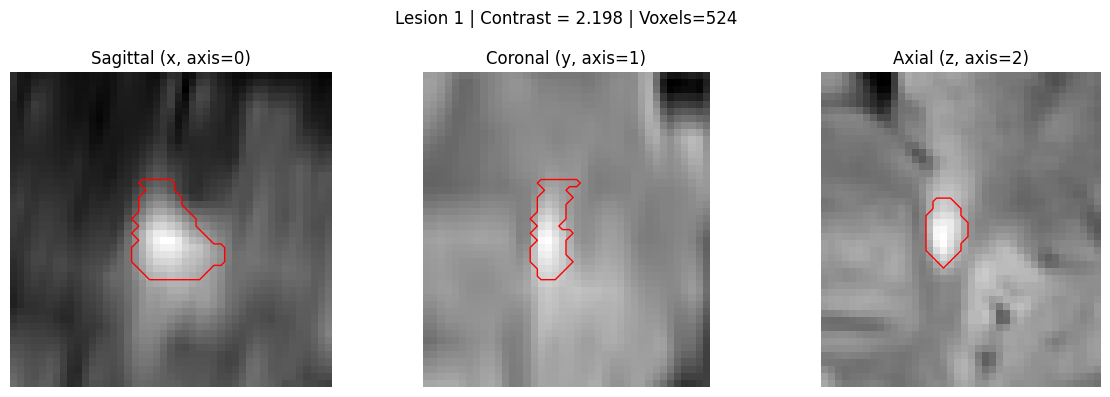

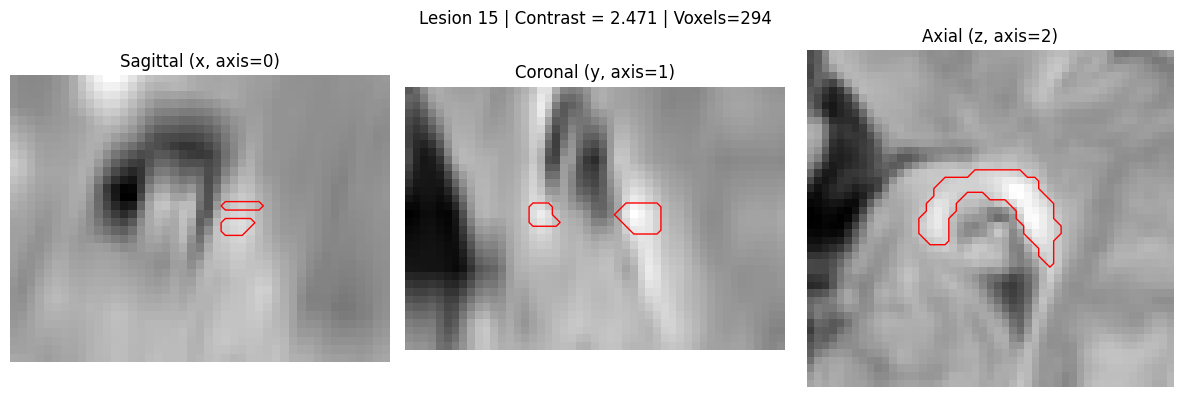

In [28]:
sel = ContrastSelection(mode="low", low_thr=2.5)
visualize_lesion_contrast(
    image_norm=normalied_img,
    lesion_label_map=lesion_cc,
    contrast=lesion_cnr,
    selection=sel,
    margin=15
)

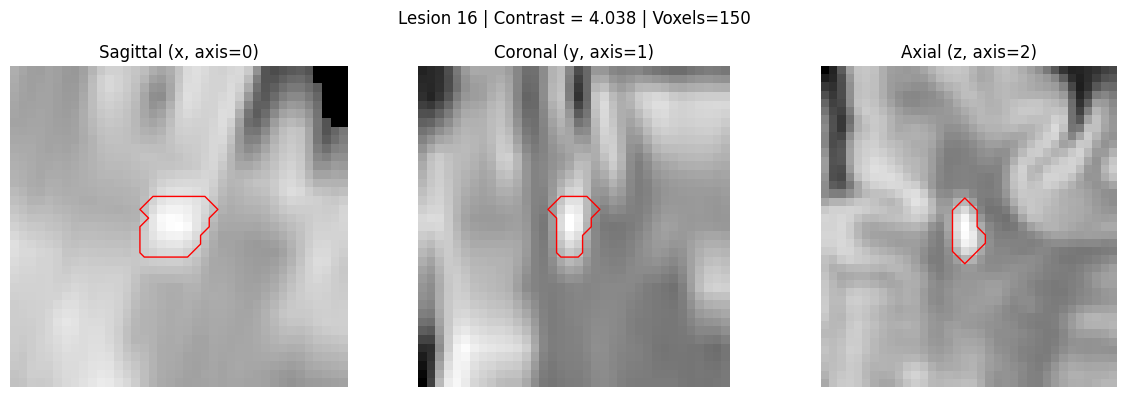

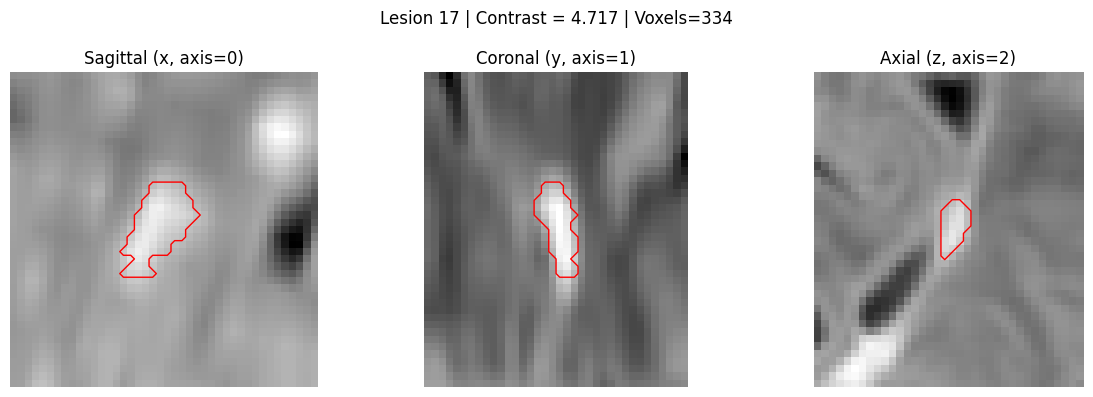

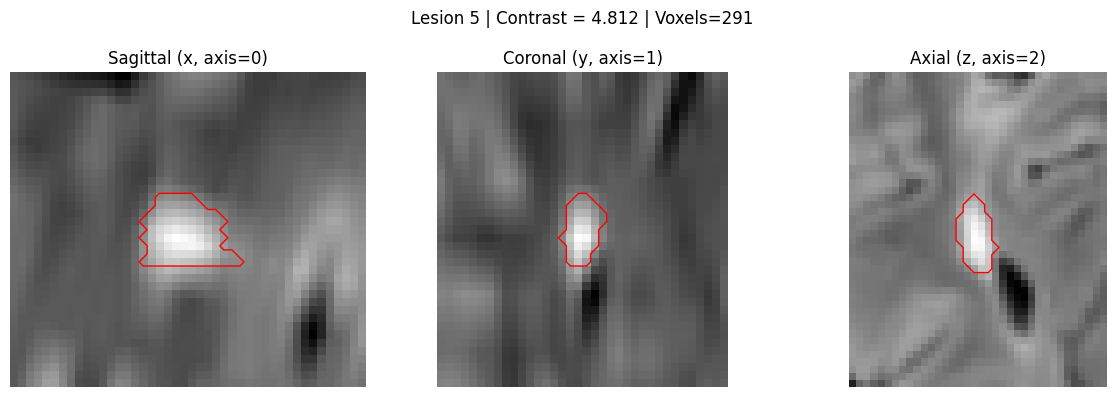

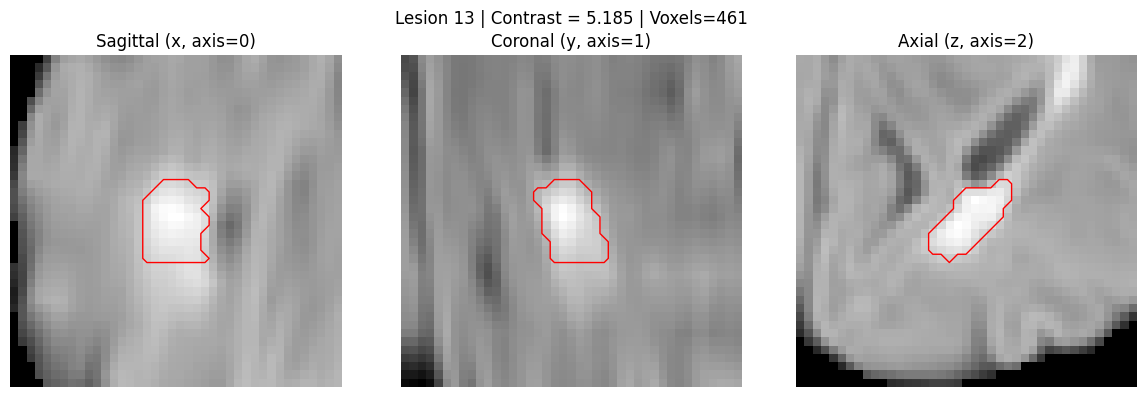

In [29]:
sel = ContrastSelection(mode="high", high_thr=4.0)
visualize_lesion_contrast(
    image_norm=normalied_img,
    lesion_label_map=lesion_cc,
    contrast=lesion_cnr,
    selection=sel,
    margin=15
)

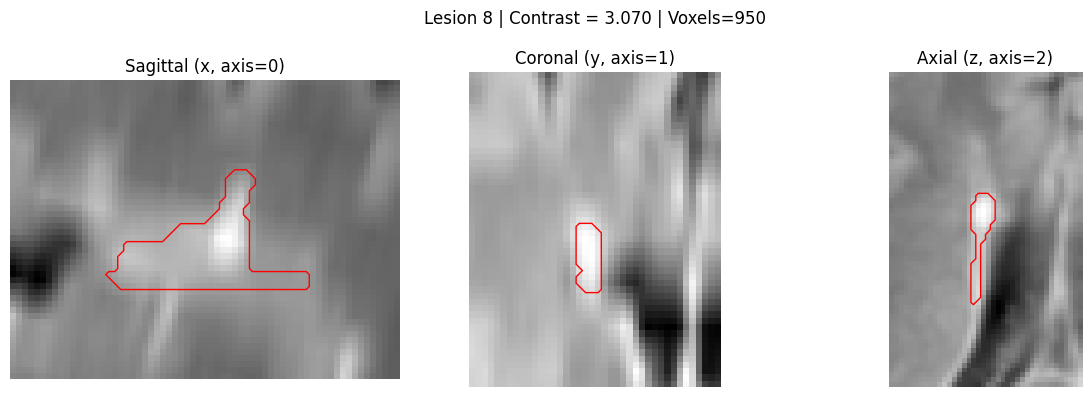

In [30]:
sel = ContrastSelection(mode="ids", lesion_ids=(8,))
visualize_lesion_contrast(
    image_norm=normalied_img,
    lesion_label_map=lesion_cc,
    contrast=lesion_cnr,
    selection=sel,
    margin=15
)

73 133 95


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: title={'center': 'MRI Slice 95 (axis=2)'}>,
        <Axes: title={'center': 'Segmentation Mask 95 (axis=2)'}>],
       dtype=object))

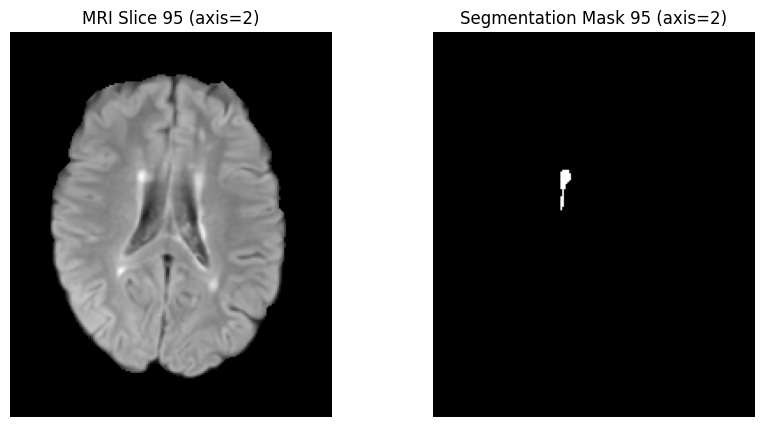

In [31]:
coords = np.where(lesion_cc == 8)
x, y, z = [int(np.round(c.mean())) for c in coords]
print(x, y, z)
show_slice_with_mask(normalied_img, (lesion_cc == 8).astype(int), z, axis=2)

### Sharpness boundary

For MS lesions, boundary sharpness reflects:

- How rapidly intensity changes from lesion → normal-appearing white matter
- How confident and localized the transition zone is
- How well-defined the lesion edge is spatially

Mathematically, this is about local gradients, contrast, and spatial uncertainty around the lesion border.

In [18]:
stat = boundary_band_gradient_sharpness(img, mask, spacing=zoom, band_iters=1)
stat

{'n_band_voxels': 19422,
 'sharpness': 1125.1092529296875,
 'mean': 1284.9266357421875,
 'median': 1125.1092529296875,
 'std': 718.1758422851562,
 'p10': 555.6143188476562,
 'p90': 2220.63134765625,
 'p95': 2675.985595703125,
 'max': 5034.27490234375}

In [19]:
from utils import boundary_sharpness_scalar, visualize_boundary_sharpness

In [20]:
lesion_id = 8
lesion_mask = (lesion_cc == lesion_id)

sharp = boundary_sharpness_scalar(
    image=normalied_img,        # ideally z-score normalized within brain
    lesion_mask=lesion_mask,
    spacing=zoom,
    sigma_mm=1.0,
    band_iters=1,
    summary="median",        # or "p90", "trimmed_mean"
)

In [21]:
# Compute boundary band gradient sharpness for each lesion

for lesion_id in range(1, n_lesions + 1):
    lesion_mask = (lesion_cc == lesion_id)
    sharpness = boundary_sharpness_scalar(
        image=normalied_img,        # ideally z-score normalized within brain
        lesion_mask=lesion_mask,
        spacing=zoom,
        sigma_mm=1.0,
        band_iters=1,
        summary="median",        # or "p90", "trimmed_mean"
    )
    print(f"Lesion {lesion_id}: Sharpness={sharpness:.4f}")


Lesion 1: Sharpness=8.5609
Lesion 2: Sharpness=5.8642
Lesion 3: Sharpness=4.9300
Lesion 4: Sharpness=5.6937
Lesion 5: Sharpness=10.3201
Lesion 6: Sharpness=7.8132
Lesion 7: Sharpness=6.5462
Lesion 8: Sharpness=9.7160
Lesion 9: Sharpness=7.8789
Lesion 10: Sharpness=8.4819
Lesion 11: Sharpness=6.9905
Lesion 12: Sharpness=6.2630
Lesion 13: Sharpness=9.3717
Lesion 14: Sharpness=7.4422
Lesion 15: Sharpness=8.3216
Lesion 16: Sharpness=6.7272
Lesion 17: Sharpness=9.3513
Lesion 18: Sharpness=2.8907
Lesion 19: Sharpness=7.0176


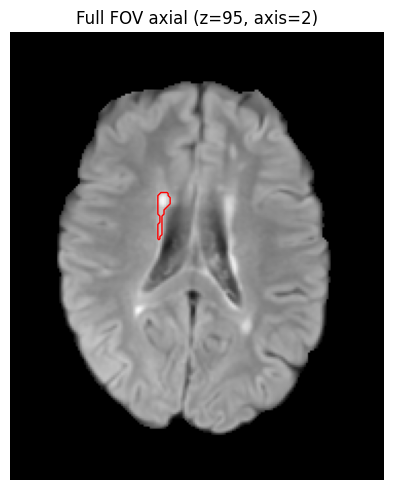

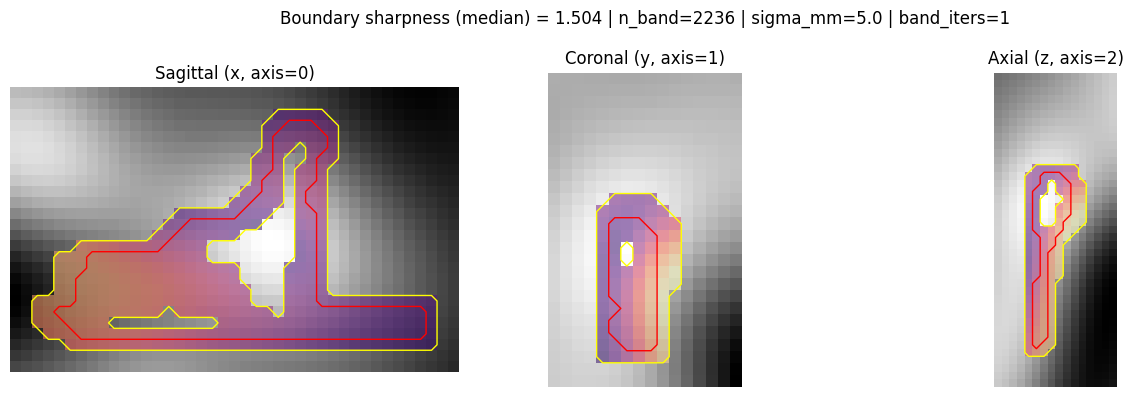

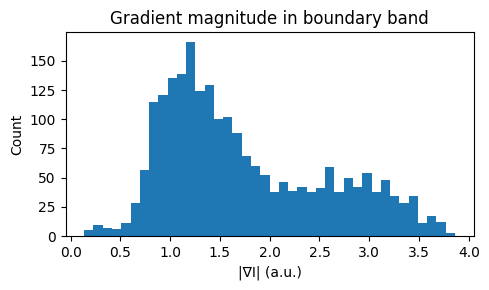

In [23]:
lesion_id = 8
lesion_mask = (lesion_cc == lesion_id)

visualize_boundary_sharpness(
    image=normalied_img,          # best: brain-masked zscore image
    lesion_mask=lesion_mask,
    spacing=zoom,
    sigma_mm=5.0,
    band_iters=1,
    summary="median",          # or "p90" / "trimmed_mean"
    show_full_context=True,    # optional sanity check
)

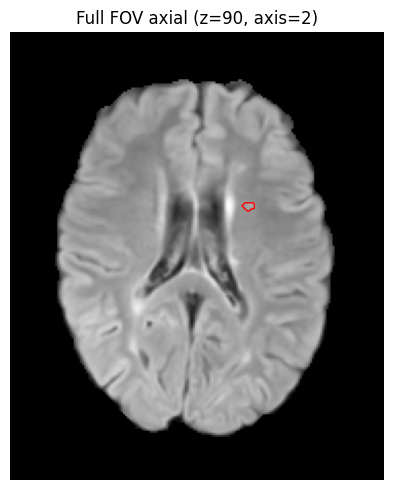

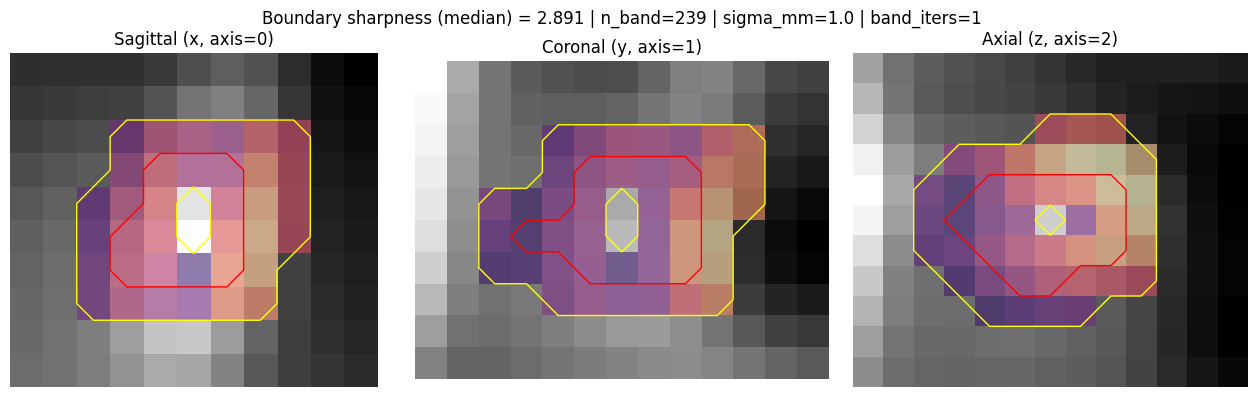

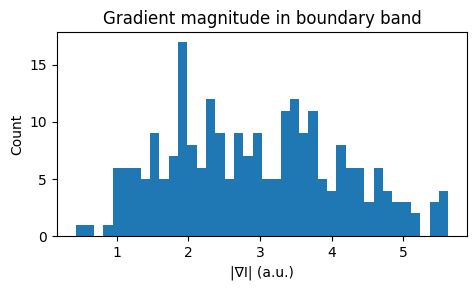

In [24]:
lesion_id = 18
lesion_mask = (lesion_cc == lesion_id)

visualize_boundary_sharpness(
    image=normalied_img,          # best: brain-masked zscore image
    lesion_mask=lesion_mask,
    spacing=zoom,
    sigma_mm=1.0,
    band_iters=1,
    summary="median",          # or "p90" / "trimmed_mean"
    show_full_context=True,    # optional sanity check
)

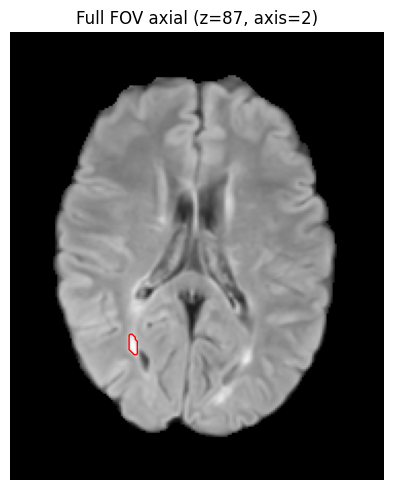

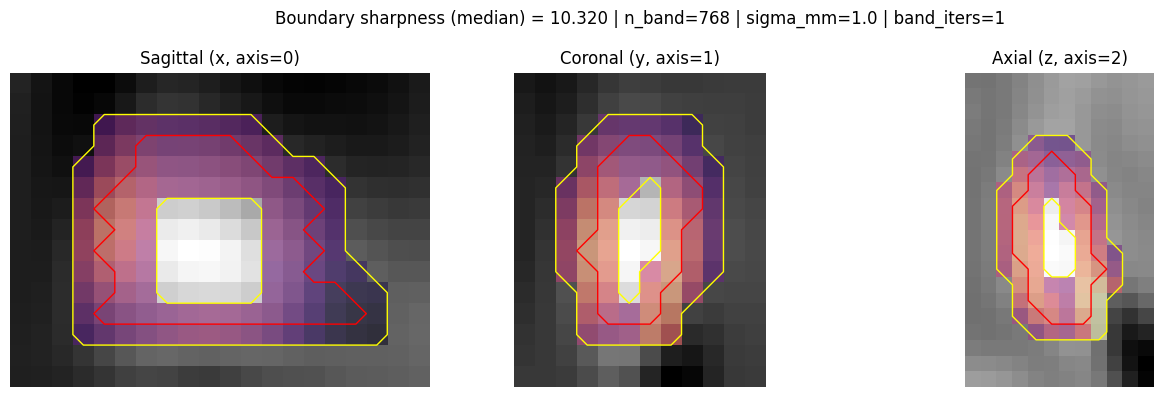

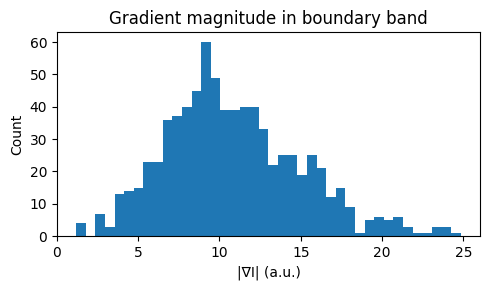

In [25]:
lesion_id = 5
lesion_mask = (lesion_cc == lesion_id)

visualize_boundary_sharpness(
    image=normalied_img,          # best: brain-masked zscore image
    lesion_mask=lesion_mask,
    spacing=zoom,
    sigma_mm=1.0,
    band_iters=1,
    summary="median",          # or "p90" / "trimmed_mean"
    show_full_context=True,    # optional sanity check
)

## Lesion Profile

In [1]:
import nibabel as nib
from utils import *

In [2]:
img_path = "/Volumes/BACH2TB/Datasets/MSLesSeg/27919209/MSLesSeg Dataset/train/P49/T2/P49_T2_FLAIR.nii.gz"
mask_path = "/Volumes/BACH2TB/Datasets/MSLesSeg/27919209/MSLesSeg Dataset/train/P49/T2/P49_T2_MASK.nii.gz"

lesion_metrics_to_csv(
    image_path=img_path,
    mask_path=mask_path,
    out_csv="lesion_profile_MSLesSeg_P49_T2.csv"
)

[{'lesion_id': 1.0,
  'volume_mm3': 524.0,
  'contrast': 2.198275808164906,
  'sharpness': 8.56094741821289},
 {'lesion_id': 2.0,
  'volume_mm3': 98.0,
  'contrast': 2.810344689760928,
  'sharpness': 5.864160060882568},
 {'lesion_id': 3.0,
  'volume_mm3': 137.0,
  'contrast': 3.842104975561849,
  'sharpness': 4.930042266845703},
 {'lesion_id': 4.0,
  'volume_mm3': 63.0,
  'contrast': 2.5517240127890646,
  'sharpness': 5.693747043609619},
 {'lesion_id': 5.0,
  'volume_mm3': 291.0,
  'contrast': 4.812499786111208,
  'sharpness': 10.320112228393555},
 {'lesion_id': 6.0,
  'volume_mm3': 367.0,
  'contrast': 3.083333211522687,
  'sharpness': 7.81315803527832},
 {'lesion_id': 7.0,
  'volume_mm3': 63.0,
  'contrast': 2.9999998577778433,
  'sharpness': 6.546228408813477},
 {'lesion_id': 8.0,
  'volume_mm3': 950.0,
  'contrast': 3.06976734032815,
  'sharpness': 9.715994834899902},
 {'lesion_id': 9.0,
  'volume_mm3': 167.0,
  'contrast': 3.216216092589942,
  'sharpness': 7.878918170928955},
 {'l

### Write lesion metrics for all test samples

In [4]:
import os

test_patients = ['P26', 'P47', 'P52', 'P2', 'P49', 'P13']
root_dir = "/Volumes/BACH2TB/Datasets/MSLesSeg/27919209/MSLesSeg Dataset/train"
for patient in test_patients:
    patient_dir = os.path.join(root_dir, patient)
    timepoints = os.listdir(patient_dir)
    for timepoint in timepoints:
        tp_dir = os.path.join(patient_dir, timepoint)
        img_path = os.path.join(tp_dir, f"{patient}_{timepoint}_FLAIR.nii.gz")
        mask_path = os.path.join(tp_dir, f"{patient}_{timepoint}_MASK.nii.gz")
        out_csv = f"lesion_profile/MSLesSeg/lesion_profile_{patient}_{timepoint}_FLAIR.csv"
        
        lesion_metrics_to_csv(
            image_path=img_path,
            mask_path=mask_path,
            out_csv=out_csv
        )

### Group lesions by metrics

In [1]:
import pandas as pd
import os

metric_dir = "lesion_profile/MSLesSeg"
csv_files = os.listdir(metric_dir)

dfs = []

for csv_file in csv_files:
    csv_path = os.path.join(metric_dir, csv_file)
    df = pd.read_csv(csv_path)
    patient_id = csv_file.replace("lesion_profile_", "").replace(".csv", "")
    df["patient_id"] = patient_id
    df["id"] = df["patient_id"] + "_lesion_" + df["lesion_id"].astype(int).astype(str)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
# df.to_csv("lesion_profile/MSLesSeg_all_lesions.csv", index=False)

In [2]:
# drop lesions with nan contrast or sharpness
df = df.dropna(subset=["contrast", "sharpness"])
df.shape

(330, 6)

In [3]:
df.head()

,lesion_id,volume_mm3,contrast,sharpness,patient_id,id
0,1.0,182.0,3.444444,7.286724,P13_T1,P13_T1_lesion_1
1,2.0,127.0,4.100000,8.293189,P13_T1,P13_T1_lesion_2
2,3.0,267.0,3.416667,8.425780,P13_T1,P13_T1_lesion_3
3,4.0,103.0,4.800000,8.450457,P13_T1,P13_T1_lesion_4
4,5.0,71.0,5.100000,9.202546,P13_T1,P13_T1_lesion_5


In [4]:
df["size_group"] = pd.cut(
    df["volume_mm3"],
    bins=[0, 50, 150, 500, float("inf")],
    labels=["very_small", "small", "medium", "large"]
)

<Axes: xlabel='size_group'>

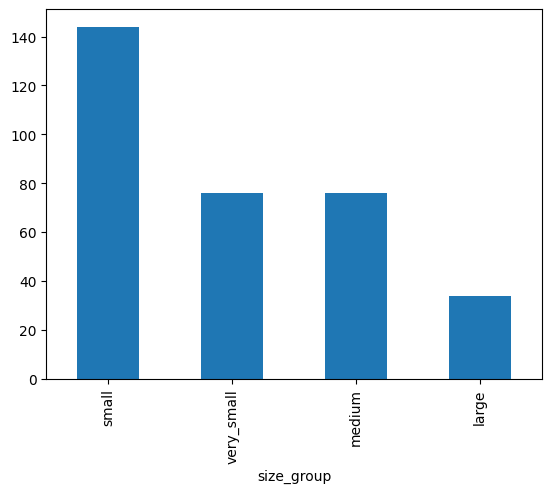

In [5]:
df["size_group"].value_counts().plot(kind="bar")

In [6]:
df["contrast_group"] = pd.qcut(
    df["contrast"],
    q=[0, 0.33, 0.66, 1.0],
    labels=["low_contrast", "mid_contrast", "high_contrast"]
)

In [7]:
df["sharpness_group"] = pd.qcut(
    df["sharpness"],
    q=[0, 0.33, 0.66, 1.0],
    labels=["blurry", "medium", "sharp"]
)

In [8]:
df

,lesion_id,volume_mm3,contrast,sharpness,patient_id,id,size_group,contrast_group,sharpness_group
0,1.0,182.0,3.444444,7.286724,P13_T1,P13_T1_lesion_1,medium,mid_contrast,blurry
1,2.0,127.0,4.100000,8.293189,P13_T1,P13_T1_lesion_2,small,mid_contrast,medium
2,3.0,267.0,3.416667,8.425780,P13_T1,P13_T1_lesion_3,medium,mid_contrast,medium
3,4.0,103.0,4.800000,8.450457,P13_T1,P13_T1_lesion_4,small,high_contrast,medium
4,5.0,71.0,5.100000,9.202546,P13_T1,P13_T1_lesion_5,small,high_contrast,medium
...,...,...,...,...,...,...,...,...,...
340,49.0,118.0,5.125000,12.744632,P47_T1,P47_T1_lesion_49,small,high_contrast,sharp
341,50.0,91.0,3.400000,9.544612,P47_T1,P47_T1_lesion_50,small,mid_contrast,medium
342,51.0,31.0,4.125000,9.037095,P47_T1,P47_T1_lesion_51,very_small,mid_contrast,medium
343,52.0,76.0,3.900000,5.979637,P47_T1,P47_T1_lesion_52,small,mid_contrast,blurry


In [9]:
# Use KMeans to cluster lesions based on volume, contrast and sharpness
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

X = df[["sharpness", "volume_mm3", "contrast"]].values    
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_scaled)
df["cluster"] = kmeans.labels_  


fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df["sharpness"], df["volume_mm3"], df["contrast"], 
    c=df["cluster"], cmap='tab10', alpha=0.6
)

ax.set_xlabel("Sharpness")
ax.set_ylabel("Volume (mm³)")
ax.set_zlabel("Contrast")
ax.set_title("KMeans Clustering of Lesions based on Volume, Contrast and Sharpness")
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [10]:
# Measure inertia to find optimal number of clusters
inertia_values = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia_values, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('KMeans Inertia vs Number of Clusters')
plt.xticks(K_range)
plt.grid()
plt.show()

NameError: name 'plt' is not defined

In [11]:
# Get groups of lesions by KMeans clusters and summarize the volume, contrast, sharpness
df.groupby("cluster").agg({
    "volume_mm3": ["mean", "std", "min", "max"],
    "contrast": ["mean", "std", "min", "max"],
    "sharpness": ["mean", "std", "min", "max"],
}).T

cluster                     0            1
volume_mm3 mean    757.865979   135.068670
           std    2138.580782   256.070142
           min      25.000000    10.000000
           max   17982.000000  3256.000000
contrast   mean      5.325829     3.581121
           std       1.440121     0.972865
           min       2.333333     1.236842
           max      11.363636     6.599999
sharpness  mean     13.048167     7.527657
           std       3.293956     2.055075
           min       6.514138     2.890668
           max      23.482584    13.416451

In [12]:
# Cluster 0: larger, higher-contrast, sharper lesions
# Cluster 1: smaller, lower-contrast, blurry lesions

In [13]:
df

,lesion_id,volume_mm3,contrast,sharpness,patient_id,id,size_group,contrast_group,sharpness_group,cluster
0,1.0,182.0,3.444444,7.286724,P13_T1,P13_T1_lesion_1,medium,mid_contrast,blurry,1
1,2.0,127.0,4.100000,8.293189,P13_T1,P13_T1_lesion_2,small,mid_contrast,medium,1
2,3.0,267.0,3.416667,8.425780,P13_T1,P13_T1_lesion_3,medium,mid_contrast,medium,1
3,4.0,103.0,4.800000,8.450457,P13_T1,P13_T1_lesion_4,small,high_contrast,medium,1
4,5.0,71.0,5.100000,9.202546,P13_T1,P13_T1_lesion_5,small,high_contrast,medium,1
...,...,...,...,...,...,...,...,...,...,...
340,49.0,118.0,5.125000,12.744632,P47_T1,P47_T1_lesion_49,small,high_contrast,sharp,0
341,50.0,91.0,3.400000,9.544612,P47_T1,P47_T1_lesion_50,small,mid_contrast,medium,1
342,51.0,31.0,4.125000,9.037095,P47_T1,P47_T1_lesion_51,very_small,mid_contrast,medium,1
343,52.0,76.0,3.900000,5.979637,P47_T1,P47_T1_lesion_52,small,mid_contrast,blurry,1


In [14]:
df[[
    "id", "patient_id", "lesion_id",
    "volume_mm3", "contrast", "sharpness",
    "cluster"
]].to_csv("lesion_profile/MSLesSeg_lesion_profile.csv", index=False)

# Compare proposed models with benchmarks visually

In [2]:
import math, os
from typing import Dict

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


def plot_model_slices(
    model_paths: Dict[str, str],
    slice_idx: int,
    cmap: str = "gray"
) -> None:

    n_models = len(model_paths)

    n_cols = 5
    n_rows = math.ceil(n_models / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3 * n_cols, 3 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for i, (model_name, path) in enumerate(model_paths.items()):
        img = nib.load(path).get_fdata()

        if slice_idx >= img.shape[-1]:
            raise ValueError(
                f"slice_idx {slice_idx} exceeds depth {img.shape[-1]}"
            )

        slice_img = img[..., slice_idx]

        axes[i].imshow(slice_img, cmap=cmap)
        axes[i].set_title(model_name, fontsize=10)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [25]:
GT_DIR = "/Volumes/BACH2TB/Projects/SmallLesionMRI/labelsTs"
PRED_DIR = "/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints"
CASE_ID = "P2_T1" # hardest case: P49_T2, easiest case: P2_T1
models = [
    "CAT",
    "MIL",
    "CATMIL",
    "nnUNet",
    "SegResNet",
    "SwinUNETR",
    "UMambaBot",
    "UMambaEnc",
    "UNETR"
]
model_dict = {
    model: os.path.join(PRED_DIR, model, f"{CASE_ID}.nii.gz")
    for model in models
}
gt_path = os.path.join(GT_DIR, f"{CASE_ID}.nii.gz")
gt_path, model_dict

('/Volumes/BACH2TB/Projects/SmallLesionMRI/labelsTs/P2_T1.nii.gz',
 {'CAT': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints/CAT/P2_T1.nii.gz',
  'MIL': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints/MIL/P2_T1.nii.gz',
  'CATMIL': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints/CATMIL/P2_T1.nii.gz',
  'nnUNet': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints/nnUNet/P2_T1.nii.gz',
  'SegResNet': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints/SegResNet/P2_T1.nii.gz',
  'SwinUNETR': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints/SwinUNETR/P2_T1.nii.gz',
  'UMambaBot': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints/UMambaBot/P2_T1.nii.gz',
  'UMambaEnc': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints/UMambaEnc/P2_T1.nii.gz',
  'UNETR': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/lastest_checkpoints

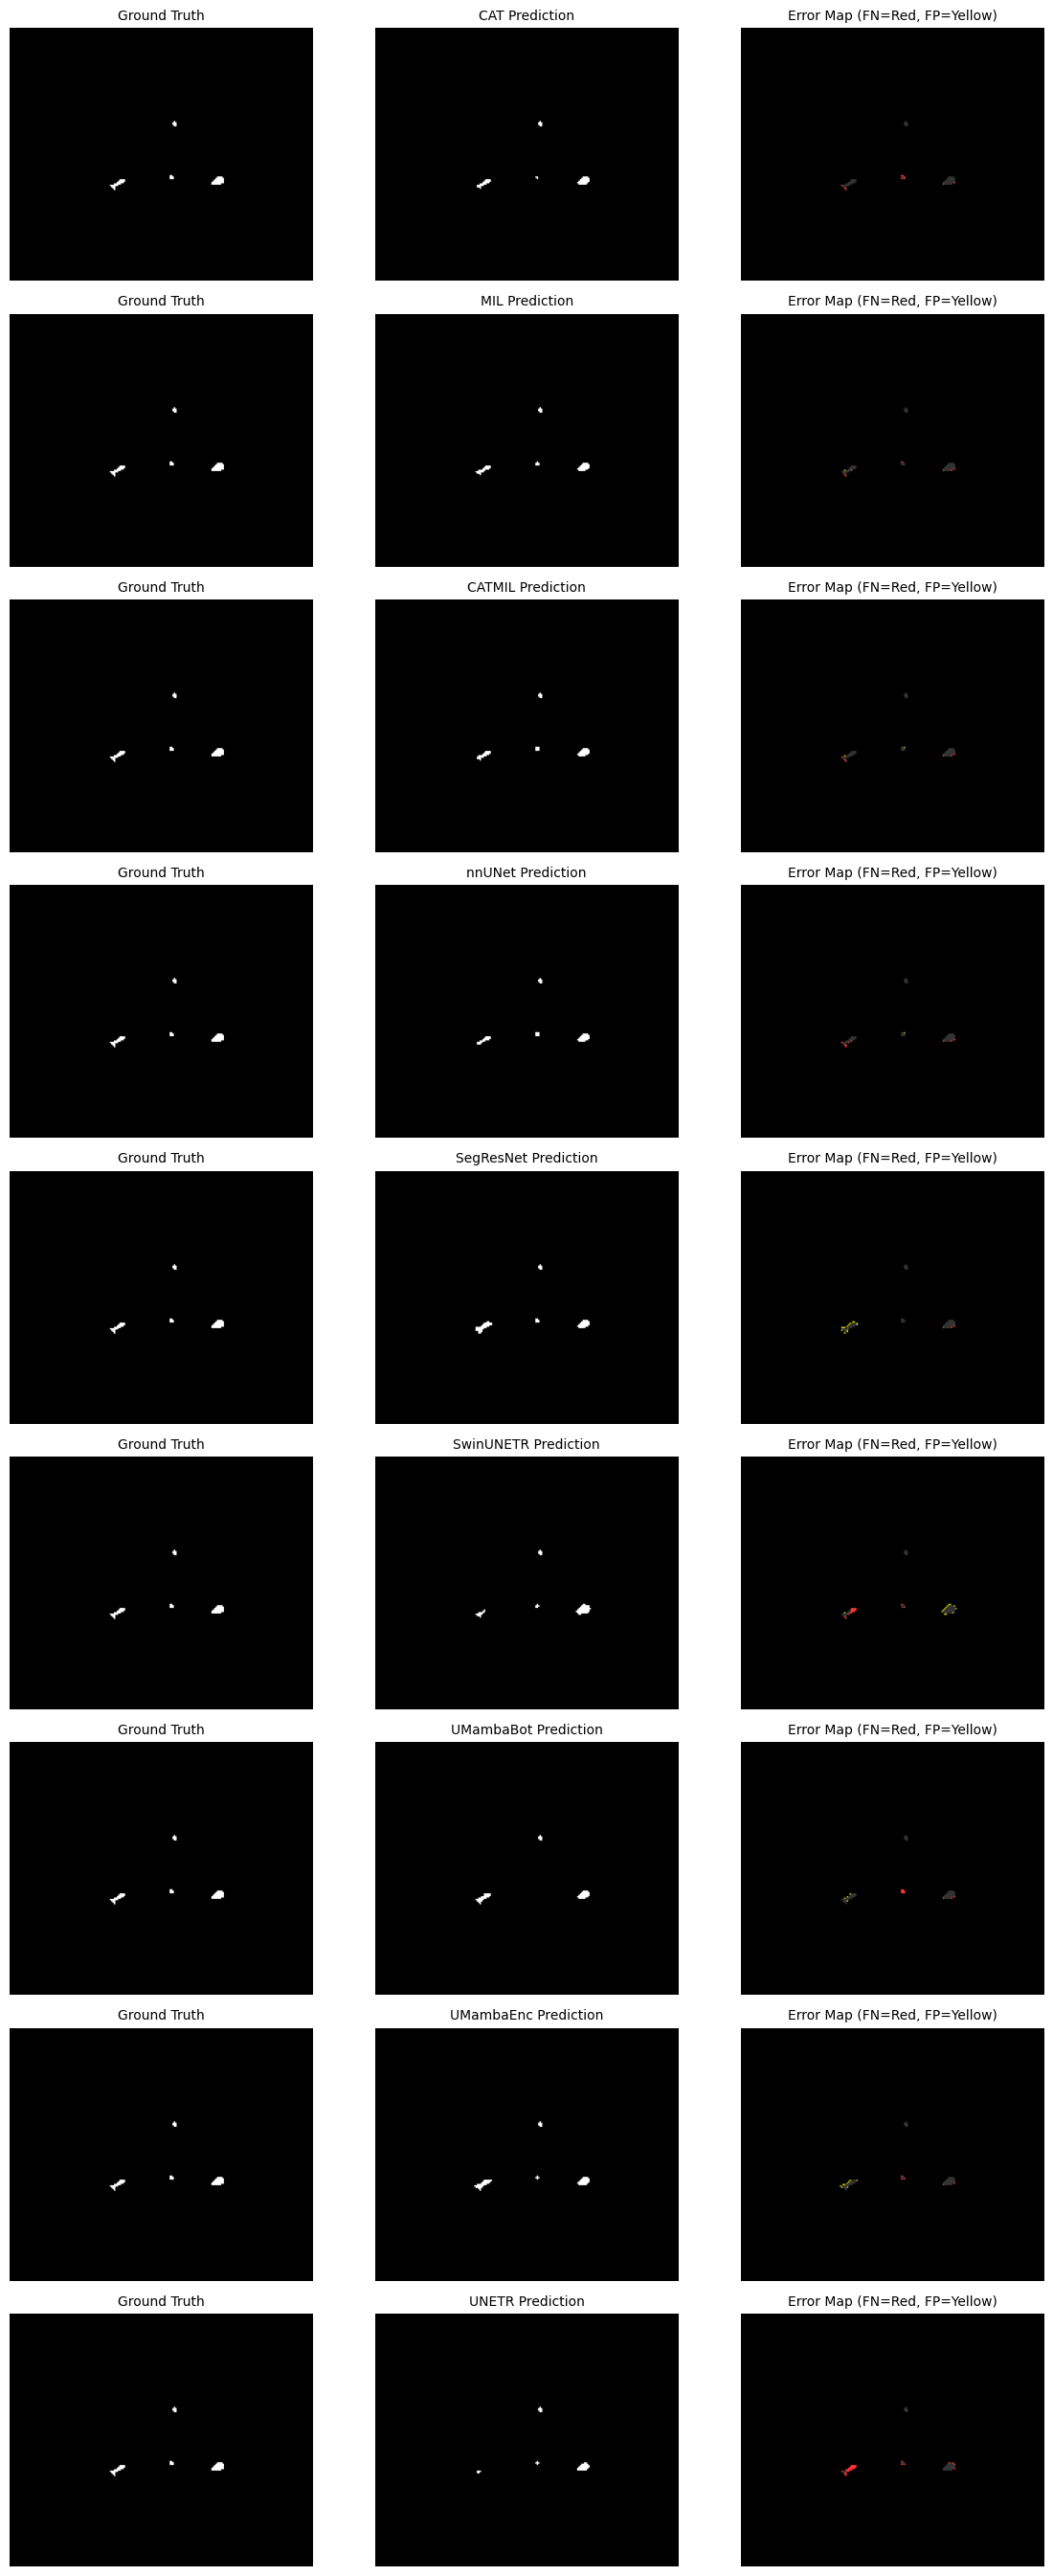

In [28]:
n_rows = len(model_dict)
n_cols = 3
slice_idx = 80

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows)
)

gt = nib.load(gt_path).get_fdata()
slice_gt = (gt[..., slice_idx] > 0).astype(np.uint8)

for i, (model_name, path) in enumerate(model_dict.items()):
    pred = nib.load(path).get_fdata()
    slice_pred = (pred[..., slice_idx] > 0).astype(np.uint8)

    # FN: GT=1, Pred=0
    fn = (slice_gt == 1) & (slice_pred == 0)

    # FP: GT=0, Pred=1
    fp = (slice_gt == 0) & (slice_pred == 1)

    # ---------------- Column 1: Ground Truth ----------------
    axes[i, 0].imshow(slice_gt, cmap="gray")
    axes[i, 0].set_title("Ground Truth", fontsize=10)
    axes[i, 0].axis("off")

    # ---------------- Column 2: Raw Prediction ----------------
    axes[i, 1].imshow(slice_pred, cmap="gray")
    axes[i, 1].set_title(f"{model_name} Prediction", fontsize=10)
    axes[i, 1].axis("off")

    # ---------------- Column 3: Overlap ----------------
    h, w = slice_gt.shape
    overlay = np.zeros((h, w, 3))

    # Red = FN
    overlay[fn, 0] = 1.0

    # Yellow = FP (Red + Green)
    overlay[fp, 0] = 1.0
    overlay[fp, 1] = 1.0

    axes[i, 2].imshow(slice_gt, cmap="gray")
    axes[i, 2].imshow(overlay, alpha=0.8)
    axes[i, 2].set_title("Error Map (FN=Red, FP=Yellow)", fontsize=10)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()